In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf 
import keras 
import seaborn as sns
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout , Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [4]:
path2='E:/7_mentor_python/PlantVillage'

In [5]:
# Using Imagedatagenerator 

In [6]:
datagen = ImageDataGenerator(
                            rescale=1/255. , 
                            rotation_range=30,
                            zoom_range=0.2,
                            shear_range=0.2,
                            horizontal_flip=True,
                            validation_split=0.2
)

In [7]:
img_size = 224
batch_size = 32 

In [8]:
train_data = datagen.flow_from_directory(path2,
                           target_size=(img_size,img_size),
                           class_mode='categorical',
                           batch_size=32,
                           subset='training'
                           )

Found 1725 images belonging to 3 classes.


In [9]:
test_data  = datagen.flow_from_directory(path2,
                            target_size=(img_size,img_size),
                           class_mode='categorical',
                           batch_size=32,
                           subset='validation',
                           shuffle=False                          
                           )

Found 430 images belonging to 3 classes.


In [10]:
labels = train_data.class_indices

In [11]:
labels

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [ ]:
train_data.classes    # y 

array([0, 0, 0, ..., 2, 2, 2], shape=(1725,), dtype=int32)

In [13]:
train_data.image_shape

(224, 224, 3)

In [14]:
train_data.num_classes

3

In [ ]:
train_data.filenames   # all train files

['Potato___Early_blight\\34f44be4-9dc5-460b-896d-cd6593166fe7___RS_Early.B 8175.JPG',
 'Potato___Early_blight\\357426c8-5b7b-4d56-9cb0-13cfaecc219f___RS_Early.B 7326.JPG',
 'Potato___Early_blight\\357b61ef-a56b-4207-aa26-161b0ef3e635___RS_Early.B 8492.JPG',
 'Potato___Early_blight\\3613b972-6af8-4a9a-be7f-bf68e4eb4cd0___RS_Early.B 6813.JPG',
 'Potato___Early_blight\\36548ca6-33b3-4a74-9b2a-52eba7aee9a3___RS_Early.B 9205.JPG',
 'Potato___Early_blight\\3682433d-fb0a-495b-a6e8-d753542b042b___RS_Early.B 8189.JPG',
 'Potato___Early_blight\\37471260-d7b4-4ccd-901e-974332ef2eb9___RS_Early.B 7967.JPG',
 'Potato___Early_blight\\37957a08-5b06-49f7-9973-29f167dd95b8___RS_Early.B 8758.JPG',
 'Potato___Early_blight\\37c72e1c-7981-4d84-9587-f5014b609230___RS_Early.B 7457.JPG',
 'Potato___Early_blight\\37d5791e-19e8-4095-a1cd-36aede6d0802___RS_Early.B 7172.JPG',
 'Potato___Early_blight\\37d94308-8783-4657-9ca6-eaca86e1015a___RS_Early.B 7825.JPG',
 'Potato___Early_blight\\37da60b5-9c33-4fe7-95d4-3a2db

In [16]:
train_data.filepaths[0]

'E:/7_mentor_python/PlantVillage\\Potato___Early_blight\\34f44be4-9dc5-460b-896d-cd6593166fe7___RS_Early.B 8175.JPG'

0


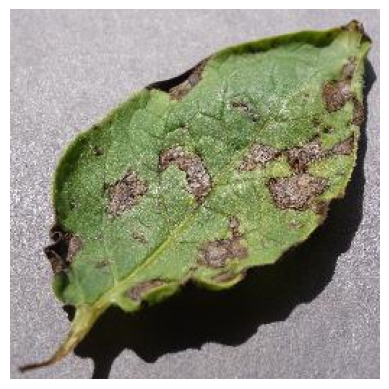

In [19]:
import matplotlib.pyplot as plt
img = tf.keras.utils.load_img(train_data.filepaths[0])
img_array = tf.keras.utils.img_to_array(img).astype("uint8")


plt.imshow(img_array)
plt.axis("off")

print(train_data.classes[0])

In [20]:
train_data.labels

array([0, 0, 0, ..., 2, 2, 2], shape=(1725,), dtype=int32)

In [21]:
train_data.color_mode

'rgb'

In [22]:
train_data.save_format

'png'

In [23]:
train_data.num_batches

54

In [24]:
train_data.workers

1

In [26]:
for i , j in train_data : 
    print(i.shape , j.shape)
    break

(32, 224, 224, 3) (32, 3)


In [27]:
# here ouput is (32, 3) >> it is one hot encoded 

In [28]:
for i , j in train_data : 
    print(i[0])
    print(j[0])
    break

[[[0.5341956  0.4557642  0.49890146]
  [0.4873019  0.4088705  0.45200774]
  [0.50202096 0.4235896  0.46672684]
  ...
  [0.4531854  0.37236407 0.39904925]
  [0.48900107 0.41449127 0.43802068]
  [0.53793305 0.46294552 0.48790795]]

 [[0.5684623  0.49003097 0.5331682 ]
  [0.5687258  0.49029443 0.5334317 ]
  [0.517209   0.43877766 0.48191494]
  ...
  [0.46522287 0.38741088 0.41259137]
  [0.5145806  0.44007084 0.46360025]
  [0.5153628  0.43887064 0.4683471 ]]

 [[0.47076276 0.39233136 0.43546864]
  [0.52899927 0.45056787 0.49370512]
  [0.5878756  0.5094442  0.5525815 ]
  ...
  [0.47726026 0.4024577  0.4261335 ]
  [0.5401602  0.4656504  0.48917982]
  [0.49279258 0.41479576 0.44878626]]

 ...

 [[0.63789064 0.58691025 0.62220436]
  [0.6823536  0.6313732  0.66666734]
  [0.5853385  0.5343581  0.5696522 ]
  ...
  [0.5159561  0.45713258 0.48458356]
  [0.5601134  0.50128984 0.5287408 ]
  [0.6042124  0.5453889  0.57283986]]

 [[0.6604609  0.6094805  0.6447746 ]
  [0.64172727 0.5907469  0.626041  ]


[0. 1. 0.]
Potato___Late_blight


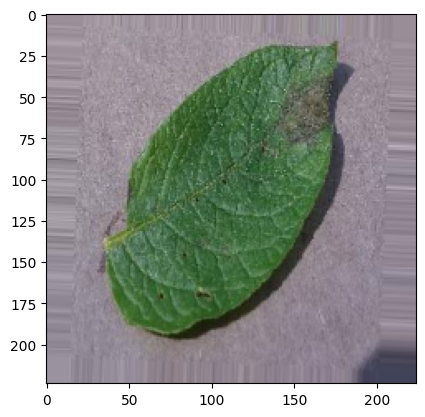

In [29]:
for i , j in train_data : 
    plt.imshow(i[0])
    print(j[0])
    a=(np.argmax(j[0]))
    r=[k for k,p in labels.items() if p==a]
    print(r[0])
    break

In [30]:
# Model Training 

In [32]:
model = keras.Sequential([
    Input(shape=(224,224,3)),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])



model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
     )

from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
es=EarlyStopping(monitor='val_loss',patience=5 , restore_best_weights=True)

history=model.fit(train_data , epochs = 30 , validation_data=test_data , callbacks =[es])

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 872ms/step - accuracy: 0.5780 - loss: 0.9168 - val_accuracy: 0.7488 - val_loss: 0.6070
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 864ms/step - accuracy: 0.8116 - loss: 0.5061 - val_accuracy: 0.8651 - val_loss: 0.3422
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 905ms/step - accuracy: 0.8823 - loss: 0.3072 - val_accuracy: 0.9209 - val_loss: 0.1869
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 997ms/step - accuracy: 0.9235 - loss: 0.2017 - val_accuracy: 0.9535 - val_loss: 0.1358
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 945ms/step - accuracy: 0.9188 - loss: 0.2277 - val_accuracy: 0.9163 - val_loss: 0.2106
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9391 - loss: 0.1761 - val_accuracy: 0.9512 - val_loss: 0.1373
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9519 - loss: 0.1392 - val_accuracy: 0.9442 - val_loss: 0.1634
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9519 - loss: 0.1252 - val_accuracy: 0.

In [33]:
model.save('potato_disease_model.keras')

In [34]:
model.evaluate(test_data)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 364ms/step - accuracy: 0.9698 - loss: 0.0749


[0.07487785816192627, 0.9697674512863159]

In [35]:
# testing data Accuracy 

In [36]:
y_pred=model.predict(test_data)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 382ms/step


In [37]:
y_pred1 = [np.argmax(i) for i in y_pred]

In [38]:
y_test = test_data.classes 

In [40]:
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score

In [41]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

0.9790697674418605
[[199   1   0]
 [  2 195   3]
 [  0   3  27]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       200
           1       0.98      0.97      0.98       200
           2       0.90      0.90      0.90        30

    accuracy                           0.98       430
   macro avg       0.96      0.96      0.96       430
weighted avg       0.98      0.98      0.98       430



In [42]:
# new img prediction  for demo 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Prediction Potato___healthy


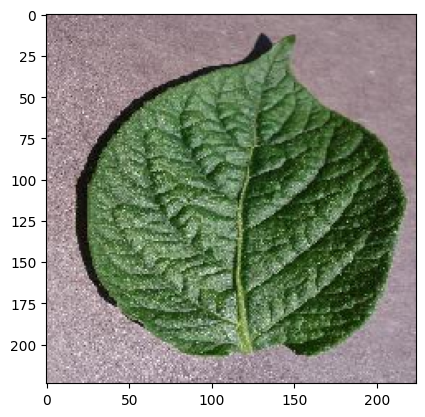

In [44]:
from tensorflow.keras.preprocessing import image

img_path = 'static/uploads/potato.jpg'
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
img = image.img_to_array(img)
img = img /255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)
class_names = list(train_data.class_indices.keys())

print("Prediction", class_names[np.argmax(prediction)])
